# 04 — Faster R-CNN Training (BDD100K) v0

Train a Faster R-CNN model with ResNet-50 FPN backbone on the BDD100K subset.
This notebook handles dataset loading, model setup, training with early stopping, and saving outputs.

In [1]:
from pathlib import Path

_here = Path.cwd().resolve()
for _root in (_here, *_here.parents):
    if (_root / "src").is_dir() and (_root / "dataset").is_dir():
        break
else:
    raise FileNotFoundError("Repo root not found (need src/ and dataset/).")

print(_root)

C:\Users\micha\Downloads\Object-Detection-main


In [2]:
import sys
import os
import numpy as np
import torch
from torch.utils.data import DataLoader
import json
import os
import shutil

project_path = str(_root)
if project_path not in sys.path:
    sys.path.append(project_path)
    sys.path.append(os.path.join(project_path, 'src'))

from src.utils import SEED, CLASS_MAP, FRCNN_CLASS_MAP, NUM_CLASSES, seed_everything, log_environment
from src.fasterrcnn_dataset import BDD100KDataset
from src.fasterrcnn_utils import collate_fn, build_fasterrcnn, train_one_epoch, val_one_epoch
from src.repeat_factor_sampler import build_repeat_factor_sampler

## 1. Environment & Seed

In [3]:
seed_everything(SEED)
log_environment()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"FRCNN_CLASS_MAP: {FRCNN_CLASS_MAP}")
print(f"NUM_CLASSES: {NUM_CLASSES}")

PyTorch: 2.11.0+cu128
Ultralytics: 8.4.42
GPU: NVIDIA GeForce RTX 5090
CUDA: 12.8
Device: cuda
FRCNN_CLASS_MAP: {'car': 1, 'person': 2, 'truck': 3, 'bus': 4, 'motor': 5, 'bike': 6, 'traffic light': 7, 'traffic sign': 8}
NUM_CLASSES: 9


## 2. Dataset & DataLoaders

In [4]:
DATASET_ROOT = _root / "outputs" / "bdd100k_preprocessing"

TRAIN_IMG_DIR = f"{DATASET_ROOT}/bdd100k-yolo-subset-v1/images/train"
VAL_IMG_DIR = f"{DATASET_ROOT}/bdd100k-yolo-subset-v1/images/val"

train_dataset = BDD100KDataset(
    image_dir=TRAIN_IMG_DIR,
    annotation_file=f"{DATASET_ROOT}/train_annotations.json",
    class_map=FRCNN_CLASS_MAP,
)

val_dataset = BDD100KDataset(
    image_dir=VAL_IMG_DIR,
    annotation_file=f"{DATASET_ROOT}/val_annotations.json",
    class_map=FRCNN_CLASS_MAP,
)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

Train samples: 7000
Val samples: 1500


In [5]:
import json
from pathlib import Path

data_root = _root / "outputs" / "bdd100k_preprocessing"
img_dir = data_root / "bdd100k-yolo-subset-v1" / "images" / "train"

with open(data_root / "train_annotations.json") as f:
    ann = json.load(f)

first_name = ann[0]["name"]

print("First annotation name:", first_name)
print("Example real image file:", next(img_dir.iterdir()).name)
print("Does first annotation path exist?", (img_dir / first_name).exists())
print("Does .jpg version exist?", (img_dir / f"{first_name}.jpg").exists())

First annotation name: 7554131a-6fa923df
Example real image file: 00067cfb-caba8a02.jpg
Does first annotation path exist? False
Does .jpg version exist? True


## 3. Repeat Factor Sampling

To address minority class imbalance by upsampling images containing rare classes (motor, bike).

Using `repeat_thresh=0.05` - classes appearing in <5% of images get upsampled.

In [6]:
sampler = build_repeat_factor_sampler( # oversampling
    dataset=train_dataset,
    num_classes=NUM_CLASSES,
    repeat_thresh=0.05,
    verbose=True,
) # v2

Computing class frequencies for repeat factor sampler...

Class sampling multipliers:
  car: freq=0.9911 -> multiplier=1.00x
  person: freq=0.3144 -> multiplier=1.00x
  truck: freq=0.2743 -> multiplier=1.00x
  bus: freq=0.1200 -> multiplier=1.00x
  motor: freq=0.0324 -> multiplier=1.24x
  bike: freq=0.0567 -> multiplier=1.00x
  traffic light: freq=0.5651 -> multiplier=1.00x
  traffic sign: freq=0.8154 -> multiplier=1.00x
  class_9: freq=0.0000 -> multiplier=1.00x


## 4. Model Setup

In [7]:
model = build_fasterrcnn(num_classes=NUM_CLASSES)
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
print(f"Trainable parameters: {sum(p.numel() for p in params):,}")

Trainable parameters: 41,112,636


## 5. Optimizer & Scheduler

In [8]:
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

print("Optimizer: SGD (lr=0.005, momentum=0.9, weight_decay=0.0005)")
print("Scheduler: StepLR (step_size=5, gamma=0.1)")

Optimizer: SGD (lr=0.005, momentum=0.9, weight_decay=0.0005)
Scheduler: StepLR (step_size=5, gamma=0.1)


## 6. DataLoaders with RFS

In [9]:
BATCH_SIZE = 6

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 1167
Val batches: 250


## 7. Training Loop

In [10]:
NUM_EPOCHS = 15
PATIENCE = 5

best_val_loss = float("inf")
epochs_no_improve = 0
history = {
    "train_loss": [],
    "val_loss": [],
    "loss_classifier": [],
    "loss_box_reg": [],
    "loss_objectness": [],
    "loss_rpn_box_reg": [],
}

In [11]:
import time

OUTPUT_DIR = _root / "outputs" / "bdd100k_project"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PRETRAINED_MODEL_OUT = OUTPUT_DIR / "fasterrcnn_pretrained.pth"
MODEL_OUT = OUTPUT_DIR / "fasterrcnn_best_oversampling.pth"

torch.save(model.state_dict(), PRETRAINED_MODEL_OUT)
print(f"Pretrained model snapshot saved to {PRETRAINED_MODEL_OUT}")

train_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, loss_components = train_one_epoch(model, optimizer, train_loader, device, epoch)
    val_loss = val_one_epoch(model, val_loader, device, epoch)
    lr_scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    for key in ["loss_classifier", "loss_box_reg", "loss_objectness", "loss_rpn_box_reg"]:
        history[key].append(loss_components.get(key, 0.0))

    print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_OUT)
        print(f"  -> Best model saved to {MODEL_OUT} (val_loss={val_loss:.4f})")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

train_time = time.time() - train_start
print(f"\nTotal training time: {train_time / 3600:.2f} hours")

Pretrained model snapshot saved to C:\Users\micha\Downloads\Object-Detection-main\outputs\bdd100k_project\fasterrcnn_pretrained.pth


Val Epoch 1: 100%|██████████| 250/250 [00:37<00:00,  6.66it/s]


Epoch 1 | Train Loss: 0.9602 | Val Loss: 0.9086
  -> Best model saved to C:\Users\micha\Downloads\Object-Detection-main\outputs\bdd100k_project\fasterrcnn_best_oversampling.pth (val_loss=0.9086)


Val Epoch 2: 100%|██████████| 250/250 [00:38<00:00,  6.47it/s]


Epoch 2 | Train Loss: 0.8449 | Val Loss: 0.9075
  -> Best model saved to C:\Users\micha\Downloads\Object-Detection-main\outputs\bdd100k_project\fasterrcnn_best_oversampling.pth (val_loss=0.9075)


...

Epoch 9 | Train Loss: 0.6401 | Val Loss: 0.9180


Val Epoch 10: 100%|██████████| 250/250 [00:37<00:00,  6.62it/s]


Epoch 10 | Train Loss: 0.6336 | Val Loss: 0.9131


Val Epoch 11: 100%|██████████| 250/250 [00:37<00:00,  6.73it/s]

Epoch 11 | Train Loss: 0.6238 | Val Loss: 0.9063
Early stopping at epoch 11

Total training time: 0.99 hours


## 6. Loss Curve

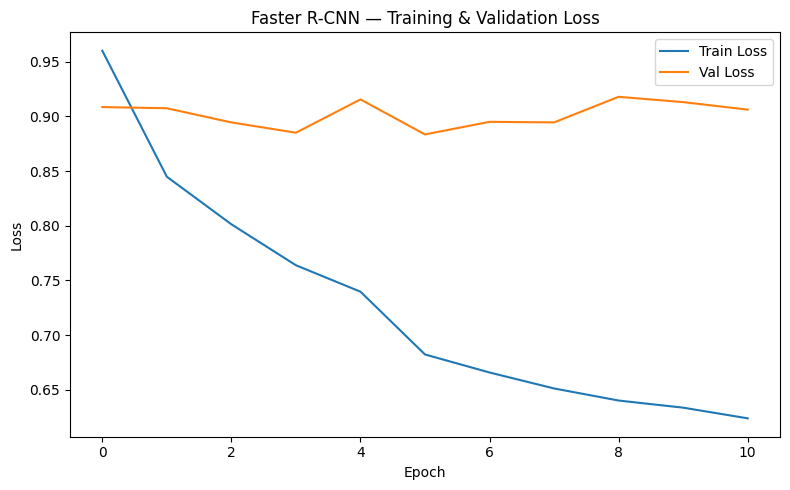

In [15]:
import matplotlib.pyplot as plt

PLOTS_DIR = OUTPUT_DIR / "results" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Faster R-CNN — Training & Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "fasterrcnn_loss_curve_oversampling.png", dpi=150)
plt.show()

## 7. Save Outputs

In [16]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

history["training_time_hours"] = train_time / 3600

history_path = OUTPUT_DIR / "fasterrcnn_loss_history_oversampling.json"
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)

plot_src = PLOTS_DIR / "fasterrcnn_loss_curve_oversampling.png"
plot_dst = OUTPUT_DIR / "fasterrcnn_loss_curve_oversampling.png"
shutil.copy(plot_src, plot_dst)

print(f"Best model saved to {MODEL_OUT}")
print(f"Loss history saved to {history_path}")
print(f"Loss curve copied to {plot_dst}")

Best model saved to C:\Users\micha\Downloads\Object-Detection-main\outputs\bdd100k_project\fasterrcnn_best_oversampling.pth
Loss history saved to C:\Users\micha\Downloads\Object-Detection-main\outputs\bdd100k_project\fasterrcnn_loss_history_oversampling.json
Loss curve copied to C:\Users\micha\Downloads\Object-Detection-main\outputs\bdd100k_project\fasterrcnn_loss_curve_oversampling.png


In [17]:
import pandas as pd

METRICS_DIR = OUTPUT_DIR / "results" / "metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.DataFrame(history)
df.index.name = "epoch"
df.index += 1

metrics_path = METRICS_DIR / "fasterrcnn_results_oversampling.csv"
df.to_csv(metrics_path)

print(f"Loss history saved to {metrics_path}")
df


Loss history saved to C:\Users\micha\Downloads\Object-Detection-main\outputs\bdd100k_project\results\metrics\fasterrcnn_results_oversampling.csv


,train_loss,val_loss,loss_classifier,loss_box_reg,loss_objectness,loss_rpn_box_reg,training_time_hours
epoch,,,,,,,
1,0.960162,0.908601,0.291861,0.439842,0.063611,0.164848,0.990565
2,0.844889,0.907518,0.244885,0.402230,0.048632,0.149141,0.990565
3,0.801354,0.894571,0.228517,0.386094,0.042562,0.144181,0.990565
4,0.763894,0.885138,0.216374,0.373038,0.036922,0.137560,0.990565
5,0.739694,0.915594,0.207323,0.366072,0.032392,0.133907,0.990565
6,0.682255,0.883570,0.188242,0.344666,0.026829,0.122519,0.990565
7,0.665782,0.895097,0.180776,0.337197,0.025664,0.122145,0.990565
8,0.651169,0.894581,0.176314,0.330147,0.024354,0.120353,0.990565
9,0.640119,0.917991,0.171844,0.325846,0.023340,0.119089,0.990565
